# Cas pratique : Construire un CNN simple avec PyTorch + Data Augmentation

## Objectif
Construire, entraîner et évaluer un petit CNN avec **PyTorch** pour classifier les images de **CIFAR-10**, avec une **data augmentation** appliquée uniquement aux données d'entraînement.

### Compétences
- charger un dataset d'images ;
- créer des transformations PyTorch ;
- visualiser l'augmentation ;
- construire un CNN avec `Conv2d`, `BatchNorm2d`, `ReLU`, `MaxPool2d`, `Flatten`, `Linear` et `Dropout` ;
- entraîner et valider le modèle ;
- évaluer le modèle sur le test set ;
- visualiser les résultats et sauvegarder les poids.

> CIFAR-10 : images RGB `32×32`, 10 classes.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')  # NVIDIA GPU
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')   # Apple Silicon GPU
else:
    device = torch.device('cpu')

print('Device :', device)

Device : mps


## Étape 01 : Comprendre le dataset

CIFAR-10 contient 50 000 images d'entraînement et 10 000 images de test. Chaque image contient 3 canaux RGB et mesure `32×32`.

Les 10 classes sont : `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.

In [2]:
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Étape 02 : Data augmentation et prétraitement

Nous utilisons deux pipelines.

### Train
`RandomCrop` et `RandomHorizontalFlip` créent des variations aléatoires. La même image peut donc être présentée différemment au réseau à différentes itérations.

### Validation / Test
Aucune augmentation aléatoire : on veut mesurer les performances sur des images non modifiées.

`ToTensor()` convertit l'image en tenseur PyTorch. `Normalize()` standardise les trois canaux avec les statistiques courantes de CIFAR-10.

# Normalisation avec `mean` et `std` calculés automatiquement

Dans cette version, les statistiques **ne sont pas écrites manuellement**.

Nous calculons automatiquement :

- `mean` = moyenne des pixels pour R, G et B ;
- `std` = écart-type des pixels pour R, G et B.

Le calcul est effectué **uniquement sur le jeu d'entraînement**. Les mêmes valeurs sont ensuite utilisées pour normaliser le train et le test. Cela évite la fuite d'information (*data leakage*).


In [3]:
# Calcul automatique des statistiques du train set

stats_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

stats_loader = DataLoader(
    stats_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    # images : [B, C, H, W]
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sq_sum += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(channel_sq_sum / num_pixels - mean ** 2)

print("Mean calculé automatiquement :", mean)
print("Std calculé automatiquement  :", std)


Mean calculé automatiquement : tensor([0.4914, 0.4822, 0.4465])
Std calculé automatiquement  : tensor([0.2470, 0.2435, 0.2616])


In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

## Étape 03 : Charger CIFAR-10 et créer train / validation

Nous séparons les 50 000 images d'entraînement en :
- 45 000 images pour le train ;
- 5 000 images pour la validation.

Pour que validation ne reçoive pas d'augmentation, nous créons deux objets `CIFAR10` partageant les mêmes données mais avec des transformations différentes.

In [5]:
full_train_aug = datasets.CIFAR10(
    root='./data', train=True, download=False, transform=train_transform
)
full_train_eval = datasets.CIFAR10(
    root='./data', train=True, download=False, transform=eval_transform
)

g = np.random.default_rng(SEED)
indices = np.arange(len(full_train_aug))
g.shuffle(indices)
train_indices = indices[:45000]
val_indices = indices[45000:]

train_dataset = Subset(full_train_aug, train_indices.tolist())
val_dataset = Subset(full_train_eval, val_indices.tolist())

test_dataset = datasets.CIFAR10(
    root='./data', train=False, download=False, transform=eval_transform
)

print('Train :', len(train_dataset))
print('Validation :', len(val_dataset))
print('Test :', len(test_dataset))

Train : 45000
Validation : 5000
Test : 10000


## Étape 04 : Visualiser l'effet de l'augmentation

La ligne `RandomCrop(32, padding=4)` ajoute d'abord 4 pixels autour de l'image, puis choisit aléatoirement un crop final de `32×32`.

`RandomHorizontalFlip()` applique parfois un retournement horizontal.

Le but est de simuler de petites variations réalistes et d'aider le modèle à généraliser.

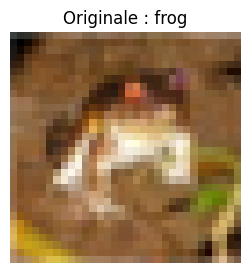

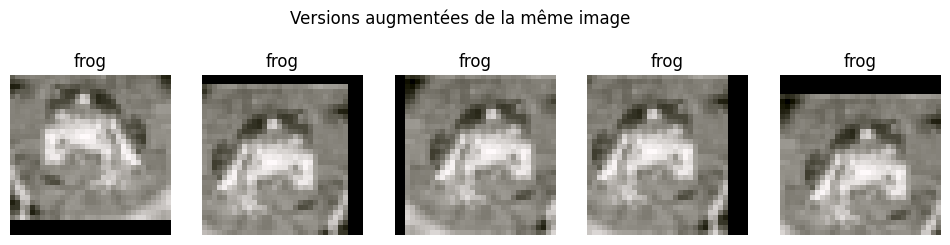

In [6]:
def unnormalize(img):
    mean_t = mean.to(device=img.device, dtype=img.dtype).view(3, 1, 1)
    std_t = std.to(device=img.device, dtype=img.dtype).view(3, 1, 1)
    return (img * std_t + mean_t).clamp(0, 1)

raw_base = datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transforms.ToTensor()
)
raw_img, label = raw_base[0]

plt.figure(figsize=(3, 3))
plt.imshow(raw_img.permute(1, 2, 0))
plt.title(f'Originale : {classes[label]}')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax in axes:
    img, lab = full_train_aug[0]  # nouvelle augmentation à chaque accès
    ax.imshow(unnormalize(img[0]).permute(1, 2, 0))
    ax.set_title(classes[lab])
    ax.axis('off')
plt.suptitle('Versions augmentées de la même image')
plt.show()

## Étape 05 : Créer les DataLoaders

Le `DataLoader` forme des mini-batches.

Ici `batch_size=128` signifie que le modèle traite 128 images avant une mise à jour des paramètres.

In [7]:
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print('Batch images :', images.shape)
print('Batch labels :', labels.shape)

Batch images : torch.Size([128, 3, 32, 32])
Batch labels : torch.Size([128])


## Étape 06 : Construire le CNN

Architecture :

```text
[B, 3, 32, 32]
      ↓
Conv 3→32 + BatchNorm + ReLU + MaxPool + Dropout
      ↓
[B, 32, 16, 16]
      ↓
Conv 32→64 + BatchNorm + ReLU + MaxPool + Dropout
      ↓
[B, 64, 8, 8]
      ↓
Flatten → 64×8×8 = 4096
      ↓
Linear 4096→128 + ReLU + Dropout
      ↓
Linear 128→10
```

Le dernier `10` correspond aux 10 classes de CIFAR-10.

In [8]:
class BetterCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = BetterCNN().to(device)
model

BetterCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.3, inplace

## Étape 07 : Vérifier les dimensions

Avant de lancer un entraînement long, testons un batch fictif.

Le modèle doit transformer une entrée `[B, 3, 32, 32]` en sortie `[B, 10]`.

In [9]:
with torch.no_grad():
    dummy = torch.zeros(2, 3, 32, 32).to(device)
    out = model(dummy)

print('Entrée :', dummy.shape)
print('Sortie :', out.shape)
assert tuple(out.shape) == (2, 10)

Entrée : torch.Size([2, 3, 32, 32])
Sortie : torch.Size([2, 10])


## Étape 08 : Loss et optimiseur

Pour une classification multi-classes :

- `CrossEntropyLoss` compare les logits avec les labels entiers `0...9` ;
- `Adam` met à jour les paramètres.

Il n'y a pas de `Softmax` dans le modèle final : `CrossEntropyLoss` attend directement les logits.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Étape 09 : Fonction d'entraînement

Pour chaque batch :
1. passage avant (`forward`) ;
2. calcul de la loss ;
3. calcul des gradients avec `backward()` ;
4. mise à jour avec `optimizer.step()`.

`model.train()` active le comportement entraînement de Dropout et BatchNorm.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

## Étape 10 : Fonction de validation

`model.eval()` désactive notamment Dropout et met BatchNorm en mode évaluation.

`torch.no_grad()` évite de calculer les gradients pendant la validation, ce qui économise mémoire et calcul.

In [12]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

## Étape 11 : Entraîner le réseau

Nous utilisons 100 époques pour un atelier. Vous pouvez augmenter `EPOCHS` ensuite pour obtenir une expérience plus longue.
Une early stopping est implémentée pour arrêter l'entraînement si la loss de validation ne s'améliore pas après un certain nombre d'époques (`PATIENCE`). Une amélioration est considérée significative si elle dépasse `MIN_DELTA`.

In [13]:
EPOCHS = 100
PATIENCE = 5
MIN_DELTA = 1e-4

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        if images.ndim == 5:
            batch_size, num_crops, channels, height, width = images.shape

            images = images.reshape(
                batch_size * num_crops, channels, height, width
            )

            crop_outputs = model(images)
            outputs = crop_outputs.reshape(
                batch_size, num_crops, -1
            ).mean(dim=1)
        else:
            outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_state = {
            name: parameter.detach().clone()
            for name, parameter in model.state_dict().items()
        }
    else:
        epochs_without_improvement += 1

    print(
        f'Epoch {epoch}/{EPOCHS} | '
        f'Train Loss={train_loss:.4f}, Train Acc={train_acc:.3%} | '
        f'Val Loss={val_loss:.4f}, Val Acc={val_acc:.3%}'
    )

    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping à l’époque {epoch}.')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'Meilleur modèle restauré : Val Loss={best_val_loss:.4f}')

Epoch 1/100 | Train Loss=1.6619, Train Acc=38.253% | Val Loss=1.2538, Val Acc=53.760%
Epoch 2/100 | Train Loss=1.2861, Train Acc=53.933% | Val Loss=1.1324, Val Acc=60.040%
Epoch 3/100 | Train Loss=1.1286, Train Acc=59.664% | Val Loss=0.9332, Val Acc=65.720%
Epoch 4/100 | Train Loss=1.0349, Train Acc=63.267% | Val Loss=0.8661, Val Acc=68.840%
Epoch 5/100 | Train Loss=0.9628, Train Acc=66.118% | Val Loss=0.8654, Val Acc=68.960%
Epoch 6/100 | Train Loss=0.9054, Train Acc=68.482% | Val Loss=0.7487, Val Acc=73.740%
Epoch 7/100 | Train Loss=0.8617, Train Acc=70.180% | Val Loss=0.8147, Val Acc=72.060%
Epoch 8/100 | Train Loss=0.8292, Train Acc=71.529% | Val Loss=0.6986, Val Acc=75.560%
Epoch 9/100 | Train Loss=0.8003, Train Acc=72.533% | Val Loss=0.6263, Val Acc=77.260%
Epoch 10/100 | Train Loss=0.7610, Train Acc=73.953% | Val Loss=0.6035, Val Acc=78.640%
Epoch 11/100 | Train Loss=0.7399, Train Acc=75.036% | Val Loss=0.6459, Val Acc=77.020%
Epoch 12/100 | Train Loss=0.7130, Train Acc=75.869% 

## Étape 12 : Visualiser les résultats

On compare le comportement du modèle sur train et validation.

Une accuracy train qui augmente fortement alors que la validation stagne ou baisse peut indiquer un overfitting.

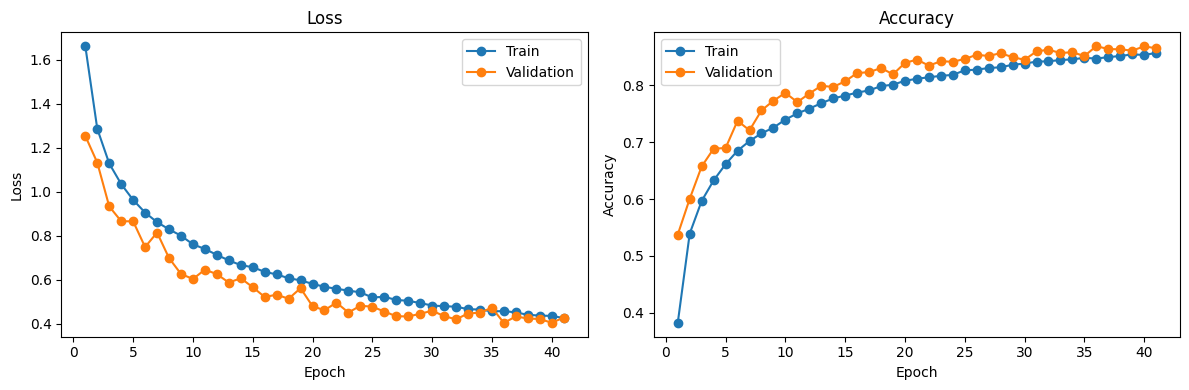

In [14]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', label='Train')
plt.plot(epochs, history['val_loss'], marker='o', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], marker='o', label='Train')
plt.plot(epochs, history['val_acc'], marker='o', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Étape 13 : Évaluation finale sur le test set

In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.3%}')

Test Loss : 0.4120
Test Accuracy : 86.580%


## Étape 14 : Quelques prédictions

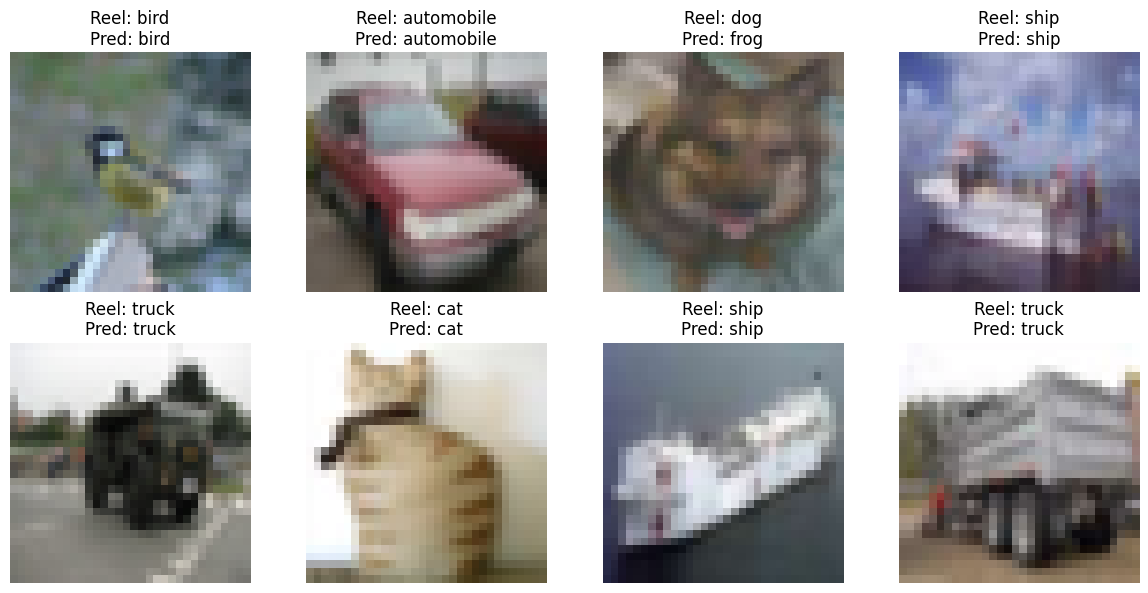

In [16]:
@torch.no_grad()
def show_predictions(model, dataset, classes, device, n=8):
    model.eval()
    chosen = np.random.choice(len(dataset), n, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, idx in zip(axes.flat, chosen):
        image, label = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()

        display_img = unnormalize(image).permute(1, 2, 0).cpu().numpy()
        ax.imshow(display_img)
        ax.set_title(f'Reel: {classes[label]}\nPred: {classes[pred]}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, classes, device)

## Étape 15 : Sauvegarder le modèle

In [17]:
# Create the model directory if it doesn't exist
import os

os.makedirs('./model', exist_ok=True)

torch.save(model.state_dict(), './model/cnn_cifar10_pytorch_augmentation_V2.pth')
print('Poids sauvegardés dans ./model/cnn_cifar10_pytorch_augmentation_V2.pth')

Poids sauvegardés dans ./model/cnn_cifar10_pytorch_augmentation_V2.pth


# Bilan : ce qu'il faut retenir

```text
Image
  ↓
Data Augmentation (train uniquement)
  ↓
ToTensor + Normalize
  ↓
Conv + BatchNorm + ReLU + Pool + Dropout
  ↓
Conv + BatchNorm + ReLU + Pool + Dropout
  ↓
Flatten
  ↓
Linear + ReLU + Dropout
  ↓
Linear → 10 classes
```

### Questions checkpoint
1. Pourquoi l'augmentation est-elle appliquée uniquement au train ?
2. Pourquoi `Linear(64*8*8, 128)` ?
3. Quel est le rôle de `BatchNorm2d(32)` ?
4. Quel est le rôle de `Dropout(0.5)` ?
5. Que signifie une sortie `[B, 10]` ?

# Réaliser par : OUARAS Khelil Rafik